# ATOM basic analysis using ServiceX-backed workflow

Minimal adaptation of the original NCB example.

In [4]:
import atlasopenmagic as atom
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import mplhep

mplhep.style.use("ATLAS")

In [5]:
atom.set_release('2025e-13tev-beta')
data_samples = atom.get_urls('data', protocol='https')
data_samples

Release '2025e-13tev-beta' already active with cached metadata.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


['simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/user/egramsta/data15_periodD.noskim.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/user/egramsta/data15_periodE.noskim.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/user/egramsta/data15_periodF.noskim.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/user/egramsta/data15_periodG.noskim.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/user/egramsta/data15_periodH.noskim.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/user/egramsta/data15_periodJ.noskim.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/user/egramsta/data16_periodA.noskim.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/user/egramsta/data16_periodB.noskim.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/user/egramsta/data16_periodC.noskim.root',
 'simplecache::https://opend

In [6]:
from servicex_analysis_utils import get_structure, ds_type_resolver

In [7]:
#removing simple cache and building serviceX Dataset object
data_samples_sx= [ds[37:] for ds in data_samples] 

In [8]:
data_samples_sx

['/eos/opendata/atlas/rucio/user/egramsta/data15_periodD.noskim.root',
 '/eos/opendata/atlas/rucio/user/egramsta/data15_periodE.noskim.root',
 '/eos/opendata/atlas/rucio/user/egramsta/data15_periodF.noskim.root',
 '/eos/opendata/atlas/rucio/user/egramsta/data15_periodG.noskim.root',
 '/eos/opendata/atlas/rucio/user/egramsta/data15_periodH.noskim.root',
 '/eos/opendata/atlas/rucio/user/egramsta/data15_periodJ.noskim.root',
 '/eos/opendata/atlas/rucio/user/egramsta/data16_periodA.noskim.root',
 '/eos/opendata/atlas/rucio/user/egramsta/data16_periodB.noskim.root',
 '/eos/opendata/atlas/rucio/user/egramsta/data16_periodC.noskim.root',
 '/eos/opendata/atlas/rucio/user/egramsta/data16_periodD.noskim.root',
 '/eos/opendata/atlas/rucio/user/egramsta/data16_periodE.noskim.root',
 '/eos/opendata/atlas/rucio/user/egramsta/data16_periodF.noskim.root',
 '/eos/opendata/atlas/rucio/user/egramsta/data16_periodG.noskim.root',
 '/eos/opendata/atlas/rucio/user/egramsta/data16_periodI.noskim.root',
 '/eos

In [9]:
random_ds=ds_type_resolver(data_samples_sx[6])

In [10]:
print(get_structure(random_ds))

Output()


---------------------------
📁 Sample: Dataset
---------------------------

File Metadata ℹ️ :

No FileMetaData found in dataset.

---------------------------

File structure with branch filter 🌿 '':


🌳 Tree: analysis
   ├── Branches:
   │   ├── num_events ; dtype: AsDtype('>f8')
   │   ├── sum_of_weights ; dtype: AsDtype('>f8')
   │   ├── sum_of_weights_squared ; dtype: AsDtype('>f8')
   │   ├── category ; dtype: AsStrings()
   │   ├── TriggerMatch_DILEPTON ; dtype: AsDtype('>f4')
   │   ├── ScaleFactor_MLTRIGGER ; dtype: AsDtype('>f4')
   │   ├── ScaleFactor_PILEUP ; dtype: AsDtype('>f4')
   │   ├── ScaleFactor_FTAG ; dtype: AsDtype('>f4')
   │   ├── mcWeight ; dtype: AsDtype('>f4')
   │   ├── xsec ; dtype: AsDtype('>f4')
   │   ├── filteff ; dtype: AsDtype('>f4')
   │   ├── kfac ; dtype: AsDtype('>f4')
   │   ├── channelNumber ; dtype: AsDtype('>u4')
   │   ├── eventNumber ; dtype: AsDtype('>u8')
   │   ├── runNumber ; dtype: AsDtype('>u4')
   │   ├── trigML ; dtype: AsDtype('bool'

In [11]:
from servicex import query, deliver


In [17]:
variables = ['lep_n','jet_n','jet_pt','jet_phi','met']

selection = (
    "(lep_n == 0)"
    " & (jet_n > 0)"
    " & (met > 100)"
    " & any(jet_pt > 150)"
)

uproot_raw_query=query.UprootRaw([{
    'treename':'analysis',
    'filter_name': variables,
    'cut': selection,
    }])
        
spec_upraw = {
    'Sample': [{
        'Name': 'Uproottest3',
        'Dataset': random_ds,
        'Query': uproot_raw_query
    }]
}


In [18]:
f=deliver(spec_upraw)


Output()

In [27]:
from servicex_analysis_utils import to_awk

In [ ]:
d = to_awk(f)

In [ ]:
plt.hist

## Define analysis variables

In [19]:
variables = ['lep_n','jet_n','jet_pt','jet_phi','met']

## Event selection (handled upstream by ServiceX)

In [60]:
selection = (
    "(lep_n == 0)"
    " & (jet_n > 0)"
    " & any(jet_pt > 150)"
    " & (met > 100)"
)

## Fetch data via ServiceX

In [62]:
skimmed_events = atom.get_data(
    data_samples_sx,
    tree="analysis",
    branch_filter=variables,
    selection=selection,
)

Output()

In [59]:
print(f"Returned object is a {type(skimmed_events)}")
print(f"With keys being the Dataset and values being arrays\n")
for key, value in list(skimmed_events.items())[:2]:
    print(f"{key}: fields = {value.fields}")

Returned object is a <class 'dict'>
With keys being the Dataset and values being arrays

/eos/opendata/atlas/rucio/user/egramsta/data15_periodD.noskim.root: fields = ['jet_n', 'njet_pt', 'jet_pt', 'njet_phi', 'jet_phi', 'lep_n', 'met']
/eos/opendata/atlas/rucio/user/egramsta/data15_periodE.noskim.root: fields = ['jet_n', 'njet_pt', 'jet_pt', 'njet_phi', 'jet_phi', 'lep_n', 'met']


## Simple analysis: leading jet phi

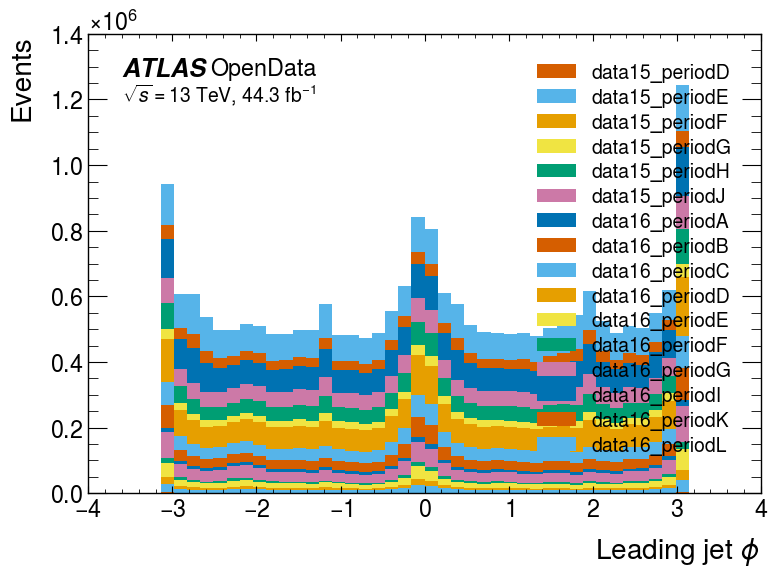

In [52]:
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import mplhep

mplhep.style.use("ATLAS")

fig, ax = plt.subplots()

all_phi = []
labels = []

for name, array in skimmed_events.items():
    label = name[40:-12]

    flat_phi = ak.flatten(array.jet_phi[:, :1])

    all_phi.append(flat_phi)
    labels.append(label)

# 👇 single call to hist with stacking
ax.hist(
    all_phi,
    bins=40,
    range=(-np.pi, np.pi),
    stacked=True,
    label=labels,
)

# Labels
ax.set_xlabel(r"Leading jet $\phi$")
ax.set_ylabel("Events")

mplhep.atlas.label(
    ax=ax,
    label="OpenData",
    data=True,
    lumi=44.3,
)

ax.legend()
plt.tight_layout()
plt.show()

### XCache 

#### First run on the ServiceX backend 
First run can be slow depending on where the data is stored, as it is fetched and downloaded localy to the endpoint. 

Example below of the ServiceX dashboard of requests sent (first try) on a testing release deployed at the AF UChicago.

Requests took between 5 and 30 mins to run (all in parallel). This includes the reading, the skimming, and the writing. 

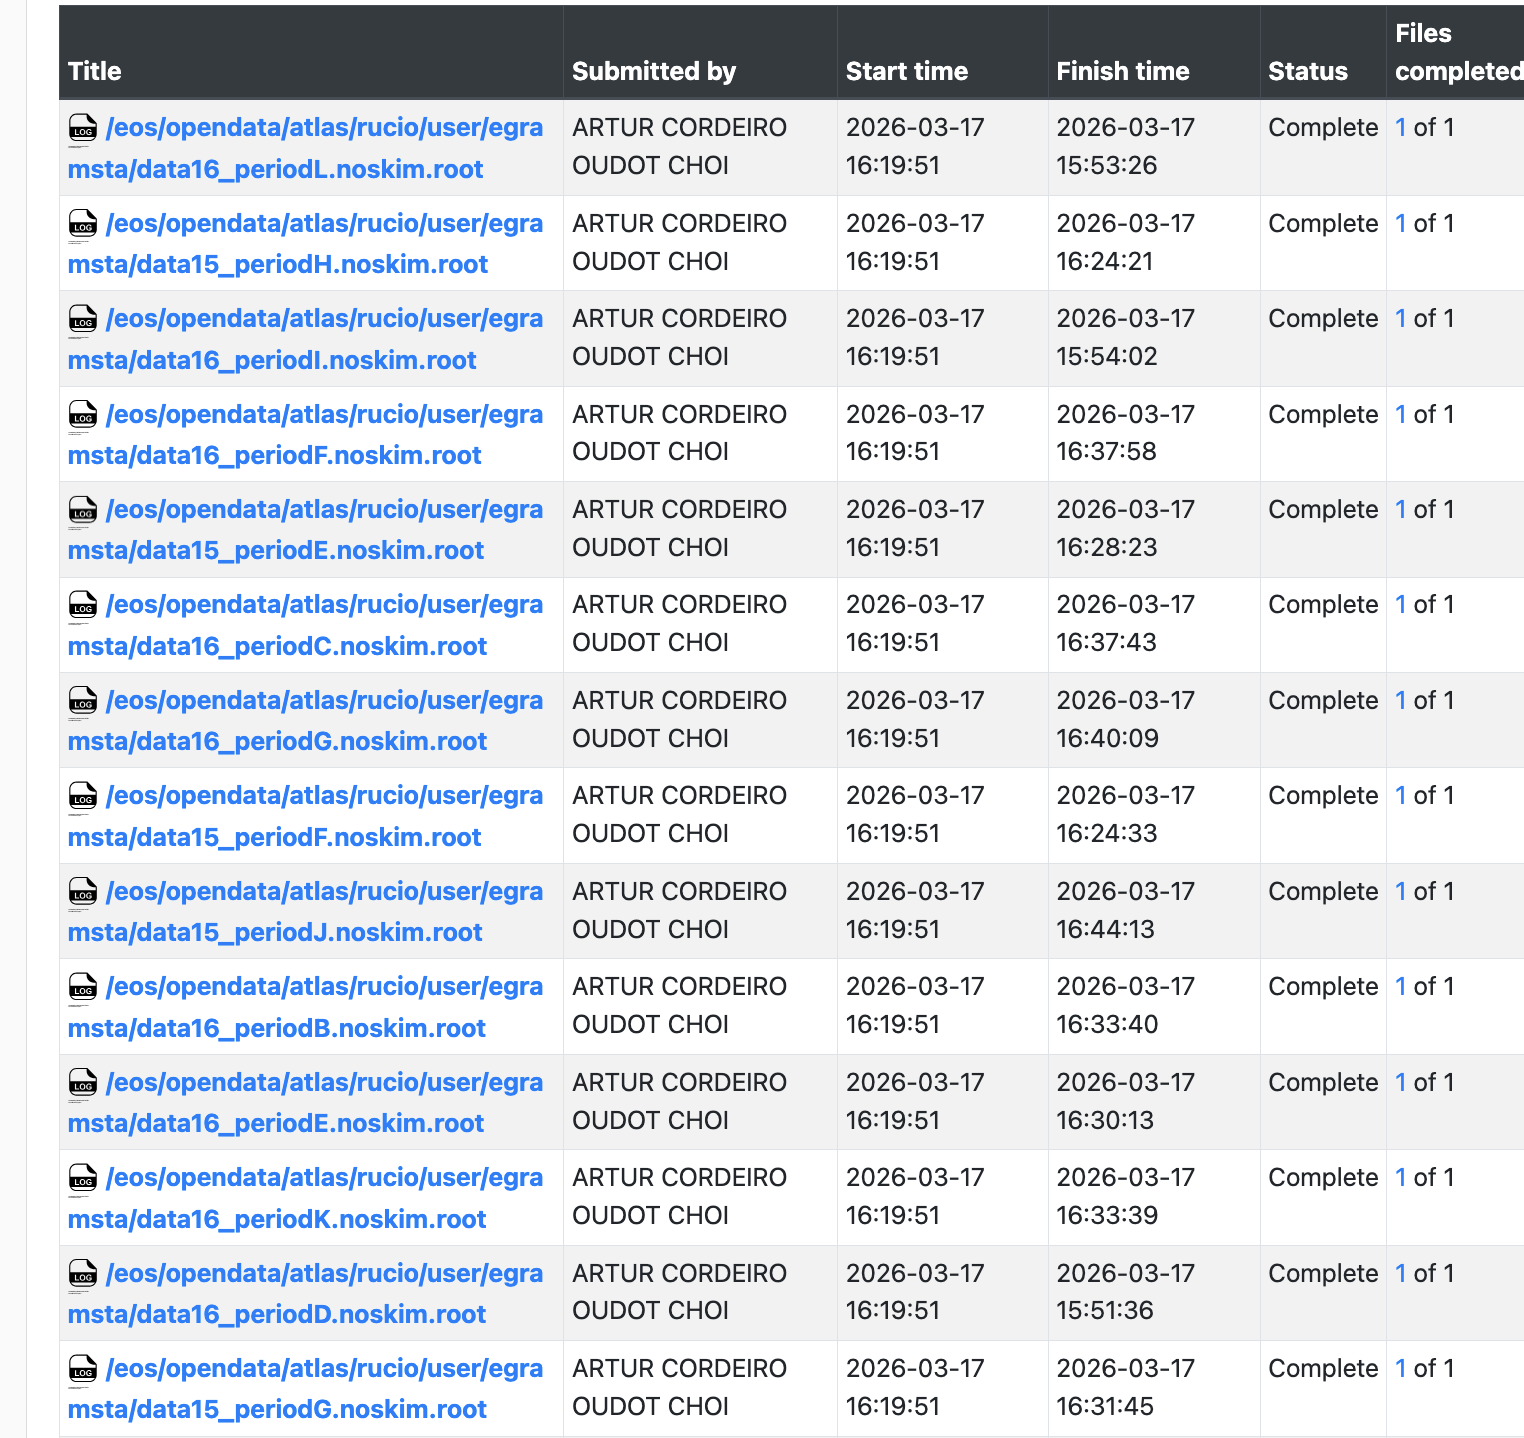


#### Further runs on the same datasets

Once the data is at the endpoint, it is stored in a XCache allow fast reading from the Kubernetes workers.
The following table shows the exact same transformations queried to the backend a 2nd time. 

In this case **all the transfomrs ran under 10 mins**. With some samples runing in 1 minute alone. 

This means that - in order to prepare a tutorial - once one user made a query all following users acessing the same samples with benefit from the XCache reading. 

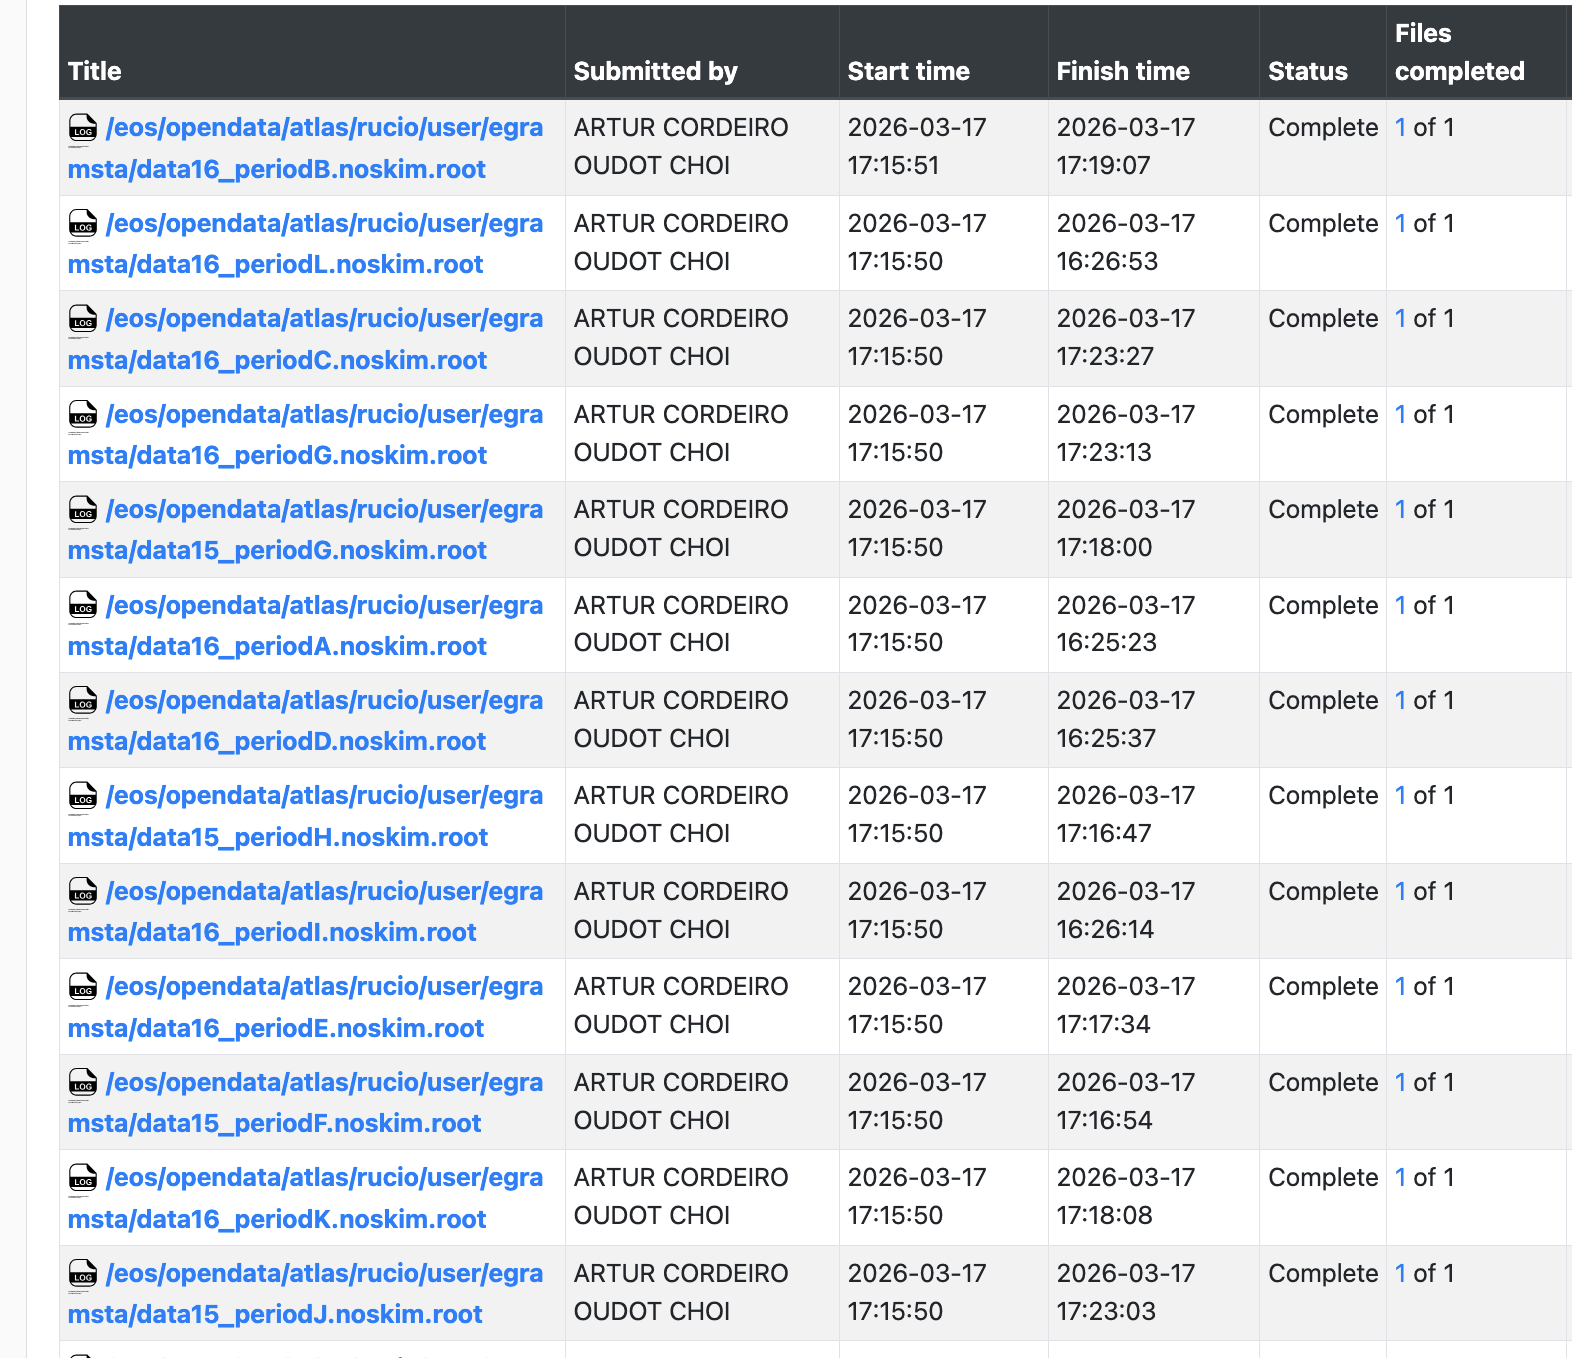

### Size of input samples 
| Size | File |
|------|------|
| 8.9G | data15_periodD.noskim.root |
| 42G  | data15_periodE.noskim.root |
| 25G  | data15_periodF.noskim.root |
| 56G  | data15_periodG.noskim.root |
| 18G  | data15_periodH.noskim.root |
| 94G  | data15_periodJ.noskim.root |
| 49G  | data16_periodA.noskim.root |
| 71G  | data16_periodB.noskim.root |
| 94G  | data16_periodC.noskim.root |
| 164G | data16_periodD.noskim.root |
| 48G  | data16_periodE.noskim.root |
| 95G  | data16_periodF.noskim.root |
| 102G | data16_periodG.noskim.root |
| 158G | data16_periodI.noskim.root |
| 63G  | data16_periodK.noskim.root |
| 175G | data16_periodL.noskim.root |
| **1.3T** | **total** |

### Size of output local files

In [78]:
skimmed_events_paths = atom.get_data(
    data_samples_sx,
    tree="analysis",
    branch_filter=variables,
    selection=selection,
    return_paths = True # Can return local paths instead of arrays where ServiceX result is downloaded
)
# THis does not re-trigger trasnformations in the backend

Output()

In [76]:
import subprocess

print("| Size | File |")
print("|------|------|")
total = 0

for original, paths in skimmed_events_paths.items():
    local_path = paths[0]  # there’s only one per key

    # Run du -sh on the file
    result = subprocess.run(
        ["du", "-sh", local_path],
        capture_output=True,
        text=True
    )

    size = result.stdout.split()[0]
    total+=float(size[:-1])

    # Extract just filename from original path
    filename = original.split("/")[-1]

    print(f"| {size} | {filename} |")
print(f"| {total}M | Total |")

| Size | File |
|------|------|
| 1.6M | data15_periodD.noskim.root |
| 13M | data15_periodE.noskim.root |
| 9.1M | data15_periodF.noskim.root |
| 21M | data15_periodG.noskim.root |
| 7.5M | data15_periodH.noskim.root |
| 41M | data15_periodJ.noskim.root |
| 12M | data16_periodA.noskim.root |
| 41M | data16_periodB.noskim.root |
| 50M | data16_periodC.noskim.root |
| 97M | data16_periodD.noskim.root |
| 28M | data16_periodE.noskim.root |
| 62M | data16_periodF.noskim.root |
| 65M | data16_periodG.noskim.root |
| 112M | data16_periodI.noskim.root |
| 40M | data16_periodK.noskim.root |
| 120M | data16_periodL.noskim.root |
| 720.2M | Total |


### Summary

As one can see we reduce from 1.3 TB of data to less than 0.7 Gb in 10 minutes on openData